
SENTINEL 11.1 — SWEEP CONTROLADO (Top 10)
 top_k  weight_cap  vol_target  score  STOP_hits  TEST_CAGR%  TEST_Sharpe  TEST_MaxDD%  TEST_Calmar  TEST_TurnoverAnn  TEST_ExcessCAGR_vsQQQ%  FULL_CAGR%  FULL_Sharpe  FULL_MaxDD%  FULL_Calmar
     3        0.65        0.26 0.2358        320     25.1446       1.1981     -25.8227       0.9737           11.2469                  7.7695     21.1241       1.1096     -25.8227       0.8180
     3        0.65        0.30 0.2331        320     26.5825       1.1681     -29.2245       0.9096           11.8626                  9.2073     22.3922       1.0913     -29.2245       0.7662
     3        0.55        0.26 0.2322        320     25.0213       1.1938     -25.9379       0.9647           11.1536                  7.6461     21.0214       1.1058     -25.9379       0.8105
     3        0.45        0.26 0.2307        320     25.0452       1.1945     -26.2976       0.9524           10.9739                  7.6700     21.0207       1.1063     -26.2976      

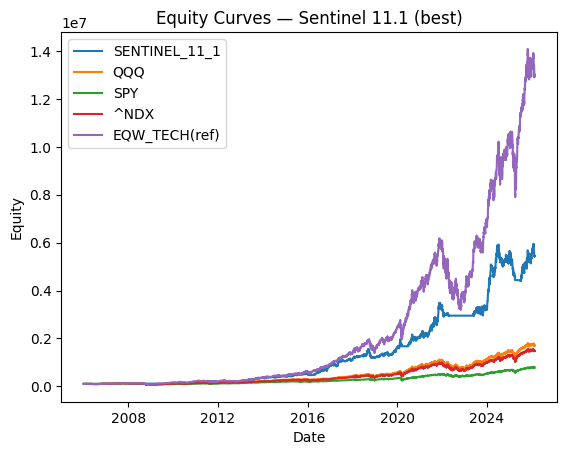

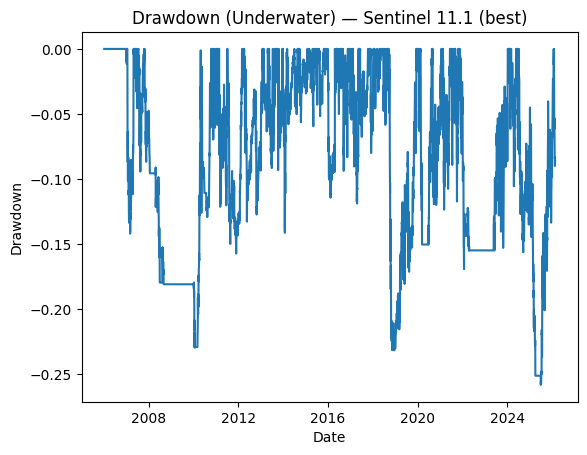

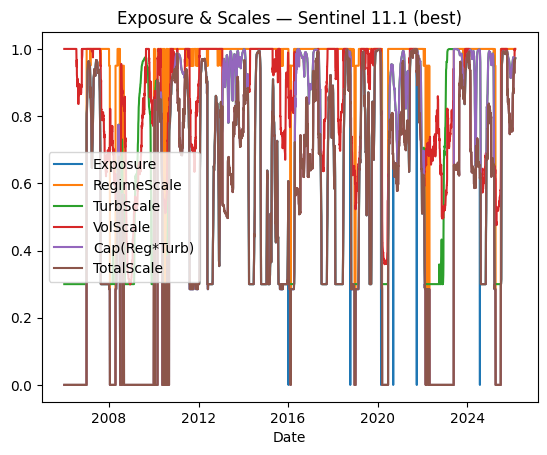

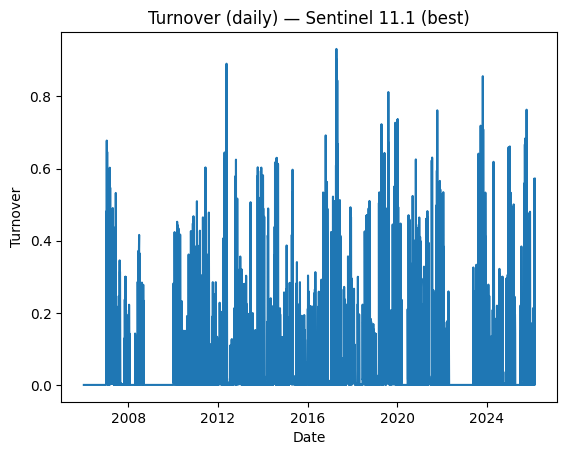

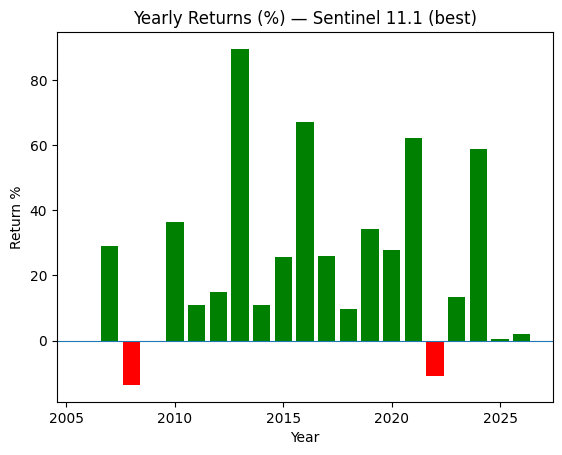

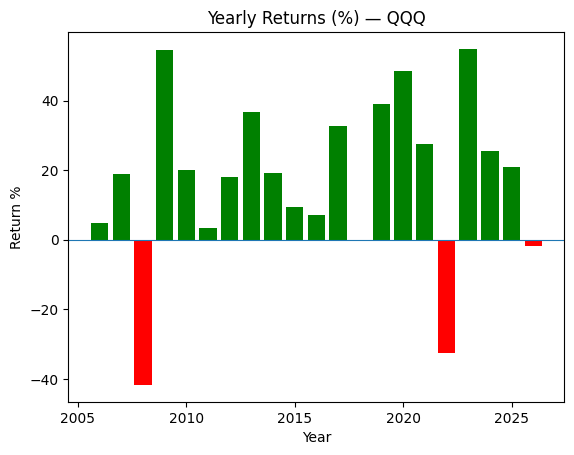


Monthly return table (%): Sentinel 11.1 (best)
Month     1      2     3      4      5      6      7      8     9      10     11    12
Year                                                                                  
2006    0.00   0.00  0.00   0.00   0.00   0.00   0.00   0.00  0.00   0.00   0.00  0.00
2007   -4.15  -4.29  1.35  13.65   8.29   5.26   6.74  -0.95  3.15   0.14  -2.82  0.99
2008   -4.65   0.00  0.00  -2.18   1.35  -8.51   0.00  -0.13 -0.03   0.00   0.00  0.00
2009    0.00   0.00  0.00   0.00   0.00   0.00   0.00   0.00  0.00   0.00   0.00  0.00
2010   -5.89   0.00  8.61  12.22  -3.03  -2.39  -1.55   0.33  8.66   9.95   5.77  0.78
2011   13.55   4.21 -1.08   1.21  -0.30   3.57  -1.69  -5.68 -1.40  -1.01  -1.05  1.27
2012    3.53  10.67  4.99  -0.46  -7.67   2.04   2.31   1.60  0.81  -6.93   4.11  0.36
2013   22.38   3.50  0.40   7.71   4.33  -4.95   5.85  10.10  9.40   1.39   2.61  5.25
2014   -6.68   9.66 -2.17   0.76   2.27   1.34  -3.36   7.82  2.67  -1.67   2.04 -

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import json
import hashlib
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

# =========================
# CONFIG
# =========================

@dataclass
class CostsConfig:
    commission: float = 0.001
    slippage: float = 0.0002
    apply_slippage: bool = True

@dataclass
class Tech11Config:
    capital_initial: float = 100000.0
    start: str = "2006-01-01"
    end: str = "2026-02-20"
    trading_days: int = 252
    rf_annual: float = 0.0

    # OOS split para reportes
    train_start: str = "2006-01-01"
    train_end: str = "2014-12-31"
    test_start: str = "2015-01-01"
    test_end: str = "2026-02-20"

    # Universo Tech (nota: fijo -> survivorship bias; benchmark real: QQQ)
    universe: Tuple[str, ...] = ('AAPL','MSFT','NVDA','GOOGL','AMZN','META','AVGO','ASML','TSM','ADBE','NFLX','AMD')

    # Benchmarks
    bench_qqq: str = "QQQ"
    bench_spy: str = "SPY"
    bench_ndx: str = "^NDX"

    # Cache
    cache_dir: str = "data_cache"

    # Rebalance y selección
    rebalance_freq: str = "W-FRI"
    top_k: int = 4  # default agresivo

    # -------- Self-tuning ER --------
    er_window: int = 30
    spans_short: Tuple[int, ...] = (42, 84, 126)
    spans_long:  Tuple[int, ...] = (63, 126, 252)
    mom_windows: Tuple[int, ...] = (63, 126, 252)
    rel_windows: Tuple[int, ...] = (63, 126)
    w_trend: float = 0.50
    w_mom: float = 0.30
    w_rel: float = 0.20
    burn_in: int = 260

    # -------- HRP --------
    hrp_window: int = 252
    weight_cap: float = 0.55  # default agresivo (más concentración controlada)

    # -------- ATR Chandelier Exit --------
    atr_window: int = 21
    k_base: float = 2.6
    k_er_gain: float = 1.2
    k_regime_gain: float = 0.6
    stop_on: bool = True
    allow_reentry: bool = True

    # -------- Regime (3 estados) --------
    regime_use: bool = True
    ma_fast: int = 50
    ma_slow: int = 200
    crisis_dd_threshold: float = 0.15
    crisis_vol_threshold: float = 0.35
    crisis_min_days: int = 3
    scale_risk_on: float = 1.00
    scale_caution: float = 0.95  # default agresivo
    scale_crisis: float = 0.00   # HARD GATE (no operabilidad real)

    # -------- Turbulence & liquidity filter --------
    turb_window: int = 63
    illiq_window: int = 21
    turb_sigmoid_a: float = 1.2
    turb_sigmoid_b: float = 0.5
    turb_scale_min: float = 0.30
    turb_eval_on_rebalance_only: bool = True  # acelera muchísimo

    # -------- Vol targeting (growth-grade) --------
    vol_target_on: bool = True
    vol_target_ann: float = 0.26  # default agresivo
    port_vol_window: int = 63
    max_exposure: float = 1.0
    min_exposure: float = 0.0

STRESS_EPISODES = {
    "GFC_2008": ("2008-01-01", "2009-06-30"),
    "EURO_2011": ("2011-07-01", "2011-12-31"),
    "Q4_2018": ("2018-10-01", "2018-12-31"),
    "COVID_2020": ("2020-02-15", "2020-06-30"),
    "RATES_2022": ("2022-01-01", "2022-12-31"),
}

# =========================
# HELPERS
# =========================

def _ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)

def _hash_key(obj: dict) -> str:
    s = json.dumps(obj, sort_keys=True).encode("utf-8")
    return hashlib.md5(s).hexdigest()

def to_1d_series(x, name="x") -> pd.Series:
    if x is None:
        return pd.Series(dtype=float, name=name)
    if isinstance(x, pd.Series):
        return x.rename(name)
    if isinstance(x, pd.DataFrame):
        if x.shape[1] == 0:
            return pd.Series(dtype=float, name=name)
        return x.iloc[:, 0].rename(name)
    arr = np.asarray(x)
    if arr.ndim == 2 and arr.shape[1] == 1:
        arr = arr.reshape(-1)
    return pd.Series(arr, name=name)

def safe_zscore(s: pd.Series, window: int = 252) -> pd.Series:
    m = s.rolling(window).mean()
    sd = s.rolling(window).std().replace(0, np.nan)
    z = (s - m) / sd
    return z.replace([np.inf, -np.inf], np.nan).fillna(0.0)

# =========================
# DATA: OHLCV with cache
# =========================

def download_ohlcv_cached(tickers: List[str], start: str, end: str, cache_dir: str) -> Dict[str, pd.DataFrame]:
    _ensure_dir(cache_dir)
    key = _hash_key({"tickers": tickers, "start": start, "end": end, "auto_adjust": True, "ohlcv": True})
    path = os.path.join(cache_dir, f"ohlcv_{key}.pkl")

    if os.path.exists(path):
        return pd.read_pickle(path)

    raw = yf.download(tickers, start=start, end=end, auto_adjust=True, group_by="ticker", progress=False)
    idx = pd.bdate_range(start=start, end=end)

    close = pd.DataFrame(index=idx)
    high  = pd.DataFrame(index=idx)
    low   = pd.DataFrame(index=idx)
    vol   = pd.DataFrame(index=idx)

    for t in tickers:
        try:
            if isinstance(raw.columns, pd.MultiIndex):
                c = raw[(t, "Close")] if (t, "Close") in raw.columns else None
                h = raw[(t, "High")]  if (t, "High")  in raw.columns else None
                l = raw[(t, "Low")]   if (t, "Low")   in raw.columns else None
                v = raw[(t, "Volume")]if (t, "Volume")in raw.columns else None
            else:
                c = raw["Close"] if "Close" in raw.columns else None
                h = raw["High"]  if "High"  in raw.columns else None
                l = raw["Low"]   if "Low"   in raw.columns else None
                v = raw["Volume"]if "Volume"in raw.columns else None

            if c is None:
                continue

            close[t] = pd.Series(c).reindex(idx).ffill(limit=5)
            high[t]  = pd.Series(h).reindex(idx).ffill(limit=5) if h is not None else close[t]
            low[t]   = pd.Series(l).reindex(idx).ffill(limit=5) if l is not None else close[t]
            vol[t]   = pd.Series(v).reindex(idx).ffill(limit=5) if v is not None else np.nan

        except Exception:
            continue

    out = {
        "close": close.dropna(how="all"),
        "high":  high.dropna(how="all"),
        "low":   low.dropna(how="all"),
        "volume":vol.dropna(how="all"),
    }
    pd.to_pickle(out, path)
    return out

# =========================
# HRP
# =========================

def hrp_weights(returns: pd.DataFrame) -> pd.Series:
    try:
        from scipy.cluster.hierarchy import linkage
        from scipy.spatial.distance import squareform
    except Exception:
        cov = returns.cov()
        iv = 1.0 / np.diag(cov)
        w = iv / iv.sum()
        return pd.Series(w, index=returns.columns)

    cov = returns.cov()
    corr = returns.corr()
    dist = np.sqrt(0.5 * (1 - corr)).clip(0, 1)
    dist_cond = squareform(dist.values, checks=False)
    link = linkage(dist_cond, method="single")

    def _get_quasi_diag(linkage_matrix):
        linkage_matrix = linkage_matrix.astype(int)
        sort_ix = pd.Series([linkage_matrix[-1, 0], linkage_matrix[-1, 1]])
        num_items = linkage_matrix[-1, 3]
        while sort_ix.max() >= num_items:
            sort_ix.index = range(0, sort_ix.shape[0] * 2, 2)
            df0 = sort_ix[sort_ix >= num_items]
            i = df0.index
            j = df0.values - num_items
            sort_ix[i] = linkage_matrix[j, 0]
            df1 = pd.Series(linkage_matrix[j, 1], index=i + 1)
            sort_ix = pd.concat([sort_ix, df1]).sort_index()
            sort_ix.index = range(sort_ix.shape[0])
        return sort_ix.tolist()

    sort_ix = _get_quasi_diag(link)
    ordered = corr.index[sort_ix]
    cov_ = cov.loc[ordered, ordered]
    w = pd.Series(1.0, index=ordered)

    def _cluster_var(cov_mat, items):
        sub = cov_mat.loc[items, items]
        iv = 1.0 / np.diag(sub)
        iv = iv / iv.sum()
        return float(iv.T @ sub.values @ iv)

    clusters = [ordered.tolist()]
    while True:
        clusters = [c for c in clusters if len(c) > 1]
        if not clusters:
            break
        new_clusters = []
        for c in clusters:
            split = len(c) // 2
            c1, c2 = c[:split], c[split:]
            var1, var2 = _cluster_var(cov_, c1), _cluster_var(cov_, c2)
            alpha = 1.0 - var1 / (var1 + var2) if (var1 + var2) != 0 else 0.5
            w[c1] *= alpha
            w[c2] *= (1 - alpha)
            new_clusters += [c1, c2]
        clusters = new_clusters

    w = w / w.sum()
    return w

# =========================
# ER + scores
# =========================

def efficiency_ratio(price: pd.Series, n: int) -> pd.Series:
    p = price
    change = (p - p.shift(n)).abs()
    vol = p.diff().abs().rolling(n).sum()
    er = (change / vol).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return er.clip(0, 1)

def trend_vote(price: pd.Series, spans: Tuple[int, ...]) -> pd.Series:
    votes = []
    for s in spans:
        ema = price.ewm(span=s, adjust=False).mean().shift(1)
        votes.append(((price > ema) & price.notna() & ema.notna()).astype(float))
    return sum(votes) / len(votes)

def compute_scores(close: pd.DataFrame, qqq_close: pd.Series, cfg: Tech11Config) -> pd.DataFrame:
    idx = close.index
    qqq = to_1d_series(qqq_close, "QQQ").reindex(idx).ffill()
    scores = pd.DataFrame(index=idx, columns=close.columns, dtype=float)

    for t in close.columns:
        p = close[t].reindex(idx).ffill()
        er = efficiency_ratio(p, cfg.er_window)
        er_star = ((er - 0.10) / 0.40).clip(0, 1)

        tr_short = trend_vote(p, cfg.spans_short)
        tr_long  = trend_vote(p, cfg.spans_long)
        trend = er_star * tr_short + (1 - er_star) * tr_long

        moms = [(p / p.shift(w) - 1.0).shift(1) for w in cfg.mom_windows]
        mom_raw = sum(moms) / len(moms)
        mom = ((mom_raw.clip(-1, 1) + 1.0) / 2.0)

        rels = []
        for w in cfg.rel_windows:
            a = (p / p.shift(w) - 1.0).shift(1)
            b = (qqq / qqq.shift(w) - 1.0).shift(1)
            rels.append(a - b)
        rel_raw = sum(rels) / len(rels)
        rel = ((rel_raw.clip(-1, 1) + 1.0) / 2.0)

        s = cfg.w_trend * trend + cfg.w_mom * mom + cfg.w_rel * rel
        s.iloc[:cfg.burn_in] = 0.0
        scores[t] = s.fillna(0.0)

    return scores.fillna(0.0)

def select_topk(scores: pd.DataFrame, k: int, freq: str) -> pd.DataFrame:
    idx = scores.index
    reb_dates = scores.resample(freq).last().index
    mask = pd.DataFrame(0.0, index=idx, columns=scores.columns)
    last = np.zeros(scores.shape[1])
    cols = list(scores.columns)
    for dt in idx:
        if dt in reb_dates:
            row = scores.loc[dt].values
            order = np.argsort(-row)
            top = set(order[:k])
            last = np.array([1.0 if i in top else 0.0 for i in range(len(cols))], dtype=float)
        mask.loc[dt] = last
    return mask.fillna(0.0)

# =========================
# ATR + Chandelier
# =========================

def atr_true(high: pd.Series, low: pd.Series, close: pd.Series, window: int) -> pd.Series:
    prev = close.shift(1)
    tr = pd.concat([(high - low).abs(), (high - prev).abs(), (low - prev).abs()], axis=1).max(axis=1)
    return tr.rolling(window).mean()

def compute_k_dynamic(er_star: pd.Series, regime_state: pd.Series, cfg: Tech11Config) -> pd.Series:
    return (cfg.k_base + cfg.k_er_gain * er_star + cfg.k_regime_gain * (regime_state - 1.0)).clip(1.6, 4.5)

def apply_chandelier_stop(weights: pd.DataFrame,
                          close: pd.DataFrame, high: pd.DataFrame, low: pd.DataFrame,
                          cfg: Tech11Config,
                          reg_state: pd.Series) -> Tuple[pd.DataFrame, int]:
    """
    Devuelve (weights_after_stop, stop_hits_total)
    """
    if not cfg.stop_on:
        return weights, 0

    out = weights.copy()
    idx = out.index
    reb_dates = out.resample(cfg.rebalance_freq).last().index
    stop_hits = 0

    for t in out.columns:
        p = close[t].reindex(idx).ffill()
        er = efficiency_ratio(p, cfg.er_window)
        er_star = ((er - 0.10) / 0.40).clip(0, 1)

        atr = atr_true(high[t].reindex(idx).ffill(), low[t].reindex(idx).ffill(), p, cfg.atr_window)
        atr = atr.fillna(method="bfill").fillna(0.0)

        k_t = compute_k_dynamic(er_star, reg_state.reindex(idx).fillna(1.0), cfg)

        wt = out[t].values
        in_pos = False
        maxp = np.nan
        stopped = False

        for i, dt in enumerate(idx):
            if dt in reb_dates and cfg.allow_reentry:
                stopped = False

            if wt[i] <= 0:
                in_pos = False
                maxp = np.nan
                continue

            if stopped:
                wt[i] = 0.0
                continue

            if not in_pos:
                in_pos = True
                maxp = float(p.iloc[i])
            else:
                maxp = max(maxp, float(p.iloc[i]))

            stop_level = maxp - float(k_t.iloc[i]) * float(atr.iloc[i])
            if float(p.iloc[i]) < stop_level:
                wt[i] = 0.0
                stopped = True
                in_pos = False
                maxp = np.nan
                stop_hits += 1

        out[t] = wt

    denom = out.sum(axis=1).replace(0, np.nan)
    out = out.div(denom, axis=0).fillna(0.0)
    return out, stop_hits

# =========================
# Regime + Turbulence
# =========================

def compute_regime(qqq_close: pd.Series, cfg: Tech11Config) -> Tuple[pd.Series, pd.Series]:
    p = to_1d_series(qqq_close, "QQQ").ffill()
    idx = p.index

    ma_f = p.ewm(span=cfg.ma_fast, adjust=False).mean()
    ma_s = p.ewm(span=cfg.ma_slow, adjust=False).mean()

    r = p.pct_change().fillna(0.0)
    vol = r.rolling(cfg.port_vol_window).std() * np.sqrt(cfg.trading_days)
    vol = vol.fillna(method="bfill").fillna(0.0)

    dd = p / p.cummax() - 1.0
    crisis_raw = ((dd <= -cfg.crisis_dd_threshold) | (vol >= cfg.crisis_vol_threshold)).astype(int)
    crisis = crisis_raw.rolling(cfg.crisis_min_days).mean().fillna(0.0) >= 0.8

    risk_on = (p > ma_s) & (ma_f >= ma_s)

    state = pd.Series(1.0, index=idx)     # caution
    state[risk_on] = 2.0
    state[crisis] = 0.0

    scale = pd.Series(cfg.scale_caution, index=idx, dtype=float)
    scale[state == 2.0] = cfg.scale_risk_on
    scale[state == 0.0] = cfg.scale_crisis  # 0.0 hard gate

    scale.iloc[:cfg.burn_in] = cfg.scale_crisis
    state.iloc[:cfg.burn_in] = 0.0
    return scale, state

def compute_turbulence(close: pd.DataFrame, volume: pd.DataFrame, qqq_close: pd.Series, cfg: Tech11Config) -> pd.Series:
    """
    TURB = z(vol_QQQ) + z(avg_corr_sector) + z(avg_illiq)
    scale_turb = sigmoid -> [turb_scale_min, 1]
    Optimizado: avg_corr se calcula solo en fechas de rebalance y se ffill.
    """
    idx = close.index
    qqq = to_1d_series(qqq_close, "QQQ").reindex(idx).ffill()
    qqq_r = qqq.pct_change().fillna(0.0)
    vol_q = (qqq_r.rolling(cfg.turb_window).std() * np.sqrt(cfg.trading_days)).fillna(0.0)

    rets = close.pct_change().fillna(0.0)

    # avg pairwise corr rolling, evaluado en rebalance (o diario si lo desactivas)
    avg_corr = pd.Series(0.0, index=idx)
    w = cfg.turb_window
    if cfg.turb_eval_on_rebalance_only:
        reb_dates = close.resample(cfg.rebalance_freq).last().index
        for dt in reb_dates:
            if dt not in idx:
                continue
            loc = idx.get_loc(dt)
            if loc < w:
                continue
            sub = rets.iloc[loc-w+1:loc+1]
            c = sub.corr().values
            n = c.shape[0]
            avg_corr.loc[dt] = (c.sum() - n) / (n*(n-1)) if n > 1 else 0.0
        avg_corr = avg_corr.replace(0, np.nan).ffill().fillna(0.0)
    else:
        for i in range(len(idx)):
            if i < w:
                continue
            sub = rets.iloc[i-w+1:i+1]
            c = sub.corr().values
            n = c.shape[0]
            avg_corr.iloc[i] = (c.sum() - n) / (n*(n-1)) if n > 1 else 0.0

    # Amihud illiq
    dv = (close * volume).replace(0, np.nan)
    illiq = (rets.abs() / dv).replace([np.inf, -np.inf], np.nan)
    illiq_avg = illiq.rolling(cfg.illiq_window).mean().mean(axis=1).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    turb = safe_zscore(vol_q, 252) + safe_zscore(avg_corr, 252) + safe_zscore(illiq_avg, 252)
    turb = turb.ewm(span=10, adjust=False).mean()  # suaviza para menos “nervios”

    a, b = cfg.turb_sigmoid_a, cfg.turb_sigmoid_b
    s = 1.0 / (1.0 + np.exp(a * (turb - b)))
    s = pd.Series(s, index=idx).clip(lower=cfg.turb_scale_min, upper=1.0)
    s.iloc[:cfg.burn_in] = cfg.turb_scale_min
    return s

# =========================
# Vol target
# =========================

def vol_target_scale(port_gross: pd.Series, cfg: Tech11Config) -> pd.Series:
    if not cfg.vol_target_on:
        return pd.Series(1.0, index=port_gross.index)
    r = to_1d_series(port_gross, "r").fillna(0.0)
    vol = r.rolling(cfg.port_vol_window).std() * np.sqrt(cfg.trading_days)
    scale = (cfg.vol_target_ann / vol).replace([np.inf, -np.inf], np.nan).fillna(1.0)
    return scale.clip(lower=cfg.min_exposure, upper=cfg.max_exposure)

# =========================
# Backtest Sentinel 11.1
# =========================

def backtest_sentinel11(ohlcv: Dict[str, pd.DataFrame], cfg: Tech11Config, costs: CostsConfig) -> Dict:
    close = ohlcv["close"][list(cfg.universe)].copy()
    high  = ohlcv["high"][list(cfg.universe)].copy()
    low   = ohlcv["low"][list(cfg.universe)].copy()
    vol   = ohlcv["volume"][list(cfg.universe)].copy()
    idx = close.index

    qqq = ohlcv["close"][cfg.bench_qqq].reindex(idx).ffill()
    spy = ohlcv["close"][cfg.bench_spy].reindex(idx).ffill()
    ndx = ohlcv["close"][cfg.bench_ndx].reindex(idx).ffill() if cfg.bench_ndx in ohlcv["close"].columns else None

    reg_scale, reg_state = compute_regime(qqq, cfg) if cfg.regime_use else (pd.Series(1.0, index=idx), pd.Series(2.0, index=idx))

    turb_scale = compute_turbulence(close, vol, qqq, cfg)

    scores = compute_scores(close, qqq, cfg)
    active_mask = select_topk(scores, cfg.top_k, cfg.rebalance_freq)

    # HRP weights on rebalance dates (hold between)
    rets = close.pct_change().fillna(0.0)
    reb_dates = close.resample(cfg.rebalance_freq).last().index

    w = pd.DataFrame(0.0, index=idx, columns=close.columns)
    last_w = pd.Series(0.0, index=close.columns)

    for dt in idx:
        if dt in reb_dates:
            sel = active_mask.loc[dt]
            names = sel[sel > 0].index.tolist()
            if len(names) == 0:
                last_w = pd.Series(0.0, index=close.columns)
            elif len(names) == 1:
                last_w = pd.Series(0.0, index=close.columns)
                last_w[names[0]] = 1.0
            else:
                lookback = rets.loc[:dt].tail(cfg.hrp_window)
                sub = lookback[names].dropna()
                if len(sub) < 60:
                    cov = sub.cov()
                    iv = 1.0 / np.diag(cov)
                    ww = pd.Series(iv / iv.sum(), index=names)
                else:
                    ww = hrp_weights(sub)

                ww = ww.clip(upper=cfg.weight_cap)
                ww = ww / ww.sum()

                last_w = pd.Series(0.0, index=close.columns)
                last_w[names] = ww.values
        w.loc[dt] = last_w.values

    # Stops
    w_stop, stop_hits = apply_chandelier_stop(w, close, high, low, cfg, reg_state)

    # Portfolio gross returns
    port_gross = (w_stop.shift(1).fillna(0.0) * rets).sum(axis=1)

    # Vol target
    vol_scale = vol_target_scale(port_gross, cfg)

    # === CAMBIO CLAVE: NO CANIBALIZAR ===
    # cap por macro+risk (regime*turb), y vol_scale opera dentro de ese cap
    cap = (reg_scale * turb_scale).clip(lower=0.0, upper=cfg.max_exposure)
    total_scale = np.minimum(vol_scale, cap).clip(lower=0.0, upper=cfg.max_exposure)

    # === CRISIS HARD GATE ===
    crisis_mask = (reg_state == 0.0)
    total_scale[crisis_mask] = 0.0

    w_scaled = w_stop.mul(total_scale, axis=0)

    # Costs via turnover on scaled weights
    dw = w_scaled.diff().abs().fillna(0.0)
    to = 0.5 * dw.sum(axis=1)
    tc = to * (costs.commission + (costs.slippage if costs.apply_slippage else 0.0))
    port_net = (port_gross * total_scale - tc).replace([np.inf, -np.inf], 0.0).fillna(0.0)

    equity = cfg.capital_initial * (1.0 + port_net).cumprod()
    exposure = w_scaled.abs().sum(axis=1).clip(0, cfg.max_exposure)

    # Bench returns/equity
    qqq_r = qqq.pct_change().fillna(0.0)
    spy_r = spy.pct_change().fillna(0.0)
    qqq_eq = cfg.capital_initial * (1.0 + qqq_r).cumprod()
    spy_eq = cfg.capital_initial * (1.0 + spy_r).cumprod()
    if ndx is not None:
        ndx_r = ndx.pct_change().fillna(0.0)
        ndx_eq = cfg.capital_initial * (1.0 + ndx_r).cumprod()
    else:
        ndx_r = None
        ndx_eq = None

    return {
        "returns_net": port_net,
        "equity": equity,
        "exposure": exposure,
        "turnover": to,
        "weights": w_stop,
        "weights_scaled": w_scaled,
        "scores": scores,
        "active_mask": active_mask,
        "reg_scale": reg_scale,
        "reg_state": reg_state,
        "turb_scale": turb_scale,
        "vol_scale": vol_scale,
        "cap": cap,
        "total_scale": total_scale,
        "stop_hits": stop_hits,
        "bench": {
            "QQQ_r": qqq_r, "QQQ_eq": qqq_eq,
            "SPY_r": spy_r, "SPY_eq": spy_eq,
            "NDX_r": ndx_r, "NDX_eq": ndx_eq
        }
    }

# =========================
# METRICS / REPORTS
# =========================

def total_return(r: pd.Series) -> float:
    r = to_1d_series(r, "r").dropna()
    return float((1.0 + r).prod() - 1.0) if len(r) else 0.0

def cagr(r: pd.Series, td=252) -> float:
    r = to_1d_series(r, "r").dropna()
    if len(r) == 0:
        return 0.0
    tr = (1.0 + r).prod() - 1.0
    return float((1.0 + tr) ** (td / len(r)) - 1.0)

def ann_vol(r: pd.Series, td=252) -> float:
    r = to_1d_series(r, "r").dropna()
    sd = r.std(ddof=1)
    return float(sd * np.sqrt(td)) if sd == sd else np.nan

def sharpe(r: pd.Series, rf_ann=0.0, td=252) -> float:
    r = to_1d_series(r, "r").dropna()
    rf_d = (1.0 + rf_ann) ** (1.0 / td) - 1.0
    ex = r - rf_d
    sd = ex.std(ddof=1)
    return float(np.sqrt(td) * ex.mean() / sd) if sd and sd == sd else 0.0

def sortino(r: pd.Series, rf_ann=0.0, td=252) -> float:
    r = to_1d_series(r, "r").dropna()
    rf_d = (1.0 + rf_ann) ** (1.0 / td) - 1.0
    ex = r - rf_d
    dn = ex.copy()
    dn[dn > 0] = 0
    sd = dn.std(ddof=1)
    return float(np.sqrt(td) * ex.mean() / sd) if sd and sd == sd else 0.0

def max_dd(eq: pd.Series) -> float:
    eq = to_1d_series(eq, "eq").dropna()
    if len(eq) == 0:
        return 0.0
    dd = eq / eq.cummax() - 1.0
    return float(dd.min())

def calmar(r: pd.Series, eq: pd.Series, td=252) -> float:
    a = cagr(r, td)
    d = max_dd(eq)
    return float(a / abs(d)) if d != 0 else np.inf

def cvar(r: pd.Series, alpha=0.05) -> float:
    x = to_1d_series(r, "r").dropna().values
    if len(x) == 0:
        return np.nan
    q = np.quantile(x, alpha)
    tail = x[x <= q]
    return float(tail.mean()) if len(tail) else float(q)

def summarize(r: pd.Series, eq: pd.Series, exposure: Optional[pd.Series], turnover: Optional[pd.Series], cfg: Tech11Config) -> Dict:
    r = to_1d_series(r, "r").replace([np.inf, -np.inf], np.nan).dropna()
    eq = to_1d_series(eq, "eq").dropna()
    exp = to_1d_series(exposure, "exp").reindex(r.index).fillna(0.0) if exposure is not None else pd.Series(np.nan, index=r.index)
    to = to_1d_series(turnover, "to").reindex(r.index).fillna(0.0) if turnover is not None else pd.Series(0.0, index=r.index)
    return {
        "FinalEquity": float(eq.iloc[-1]) if len(eq) else np.nan,
        "TotalReturn": total_return(r),
        "CAGR": cagr(r, cfg.trading_days),
        "AnnVol": ann_vol(r, cfg.trading_days),
        "Sharpe": sharpe(r, cfg.rf_annual, cfg.trading_days),
        "Sortino": sortino(r, cfg.rf_annual, cfg.trading_days),
        "MaxDD": max_dd(eq),
        "Calmar": calmar(r, eq, cfg.trading_days),
        "CVaR_5": cvar(r, 0.05),
        "AvgExposure": float(exp.mean()) if exp is not None else np.nan,
        "TimeInMkt": float((exp > 0).mean()) if exp is not None else np.nan,
        "TurnoverAnn": float(to.sum() * (cfg.trading_days / len(r))) if len(r) else 0.0,
        "Days": int(len(r)),
    }

def moving_block_bootstrap(r: pd.Series, block=20, n_samples=800, seed=42) -> Dict:
    rng = np.random.default_rng(seed)
    x = to_1d_series(r, "r").replace([np.inf, -np.inf], np.nan).dropna().values
    T = len(x)
    if T < block * 5:
        return {"dd_p50": np.nan, "dd_p95": np.nan, "ruin_prob_50dd": np.nan}
    dds = []
    for _ in range(n_samples):
        starts = rng.integers(0, T - block, size=int(np.ceil(T / block)))
        sample = np.concatenate([x[s:s + block] for s in starts])[:T]
        eq = (1.0 + sample).cumprod()
        peak = np.maximum.accumulate(eq)
        dds.append(np.min(eq / peak - 1.0))
    dds = np.array(dds)
    return {
        "dd_p50": float(np.quantile(dds, 0.50)),
        "dd_p95": float(np.quantile(dds, 0.05)),
        "ruin_prob_50dd": float(np.mean(dds < -0.5)) * 100.0
    }

def stress_report(res: Dict, episodes: Dict[str, Tuple[str, str]], cfg: Tech11Config) -> pd.DataFrame:
    r = res["returns_net"]
    exp = res["exposure"]
    out = []
    for name, (a, b) in episodes.items():
        sub = r.loc[a:b]
        if len(sub) < 40:
            continue
        ee = cfg.capital_initial * (1.0 + sub).cumprod()
        ss = summarize(sub, ee, exp.loc[sub.index], None, cfg)
        out.append({
            "Episode": name,
            "CAGR%": round(ss["CAGR"]*100, 2),
            "Sharpe": round(ss["Sharpe"], 3),
            "MaxDD%": round(ss["MaxDD"]*100, 2),
            "Calmar": round(ss["Calmar"], 3),
            "AvgExposure%": round(ss["AvgExposure"]*100, 1),
            "TimeInMkt%": round(ss["TimeInMkt"]*100, 1),
        })
    return pd.DataFrame(out)

def slice_period(res: Dict, start: str, end: str, cfg: Tech11Config) -> Dict:
    r = res["returns_net"].loc[start:end]
    eq = cfg.capital_initial * (1.0 + r).cumprod()
    exp = res["exposure"].loc[start:end]
    to = res["turnover"].loc[start:end]
    return {"r": r, "eq": eq, "exp": exp, "to": to}

def print_monthly_table(r: pd.Series, title: str):
    mr = (1.0 + r.fillna(0.0)).resample("M").prod() - 1.0
    if len(mr) == 0:
        return
    df = pd.DataFrame({"date": mr.index, "ret": mr.values})
    df["Year"] = df["date"].dt.year
    df["Month"] = df["date"].dt.month
    piv = df.pivot_table(index="Year", columns="Month", values="ret", aggfunc="mean") * 100
    print("\nMonthly return table (%):", title)
    print(piv.round(2).to_string())

# =========================
# PLOTS
# =========================

def plot_equity(curves: Dict[str, pd.Series], title: str):
    plt.figure()
    for k, s in curves.items():
        s = to_1d_series(s, k).dropna()
        if len(s):
            plt.plot(s.index, s.values, label=k)
    plt.title(title); plt.xlabel("Date"); plt.ylabel("Equity"); plt.legend(); plt.show()

def plot_drawdown(eq: pd.Series, title: str):
    eq = to_1d_series(eq, "eq").dropna()
    dd = eq / eq.cummax() - 1.0
    plt.figure()
    plt.plot(dd.index, dd.values)
    plt.title(title); plt.xlabel("Date"); plt.ylabel("Drawdown"); plt.show()

def plot_scales(res: Dict, title: str):
    exp = to_1d_series(res["exposure"], "exp").fillna(0)
    reg = to_1d_series(res["reg_scale"], "reg").fillna(0)
    turb = to_1d_series(res["turb_scale"], "turb").fillna(0)
    vol = to_1d_series(res["vol_scale"], "vol").fillna(0)
    cap = to_1d_series(res["cap"], "cap").fillna(0)
    tot = to_1d_series(res["total_scale"], "tot").fillna(0)
    plt.figure()
    plt.plot(exp.index, exp.values, label="Exposure")
    plt.plot(reg.index, reg.values, label="RegimeScale")
    plt.plot(turb.index, turb.values, label="TurbScale")
    plt.plot(vol.index, vol.values, label="VolScale")
    plt.plot(cap.index, cap.values, label="Cap(Reg*Turb)")
    plt.plot(tot.index, tot.values, label="TotalScale")
    plt.title(title); plt.xlabel("Date"); plt.legend(); plt.show()

def plot_turnover(to: pd.Series, title: str):
    to = to_1d_series(to, "to").fillna(0)
    plt.figure()
    plt.plot(to.index, to.values)
    plt.title(title); plt.xlabel("Date"); plt.ylabel("Turnover"); plt.show()

def plot_year_bars(r: pd.Series, title: str):
    yr = (1.0 + r.fillna(0.0)).resample("Y").prod() - 1.0
    if len(yr) == 0:
        return
    df = pd.DataFrame({"Year": yr.index.year, "Ret%": yr.values * 100})
    colors = ["green" if x >= 0 else "red" for x in df["Ret%"]]
    plt.figure()
    plt.bar(df["Year"], df["Ret%"], color=colors)
    plt.axhline(0, linewidth=0.8)
    plt.title(f"Yearly Returns (%) — {title}")
    plt.xlabel("Year"); plt.ylabel("Return %")
    plt.show()

# =========================
# SWEEP + RUN
# =========================

def evaluate_cfg(ohlcv: Dict[str, pd.DataFrame], cfg: Tech11Config, costs: CostsConfig, make_plots: bool = False) -> Dict:
    res = backtest_sentinel11(ohlcv, cfg, costs)

    # Bench series
    qqq_r = res["bench"]["QQQ_r"]; qqq_eq = res["bench"]["QQQ_eq"]
    spy_r = res["bench"]["SPY_r"]; spy_eq = res["bench"]["SPY_eq"]
    ndx_r = res["bench"]["NDX_r"]; ndx_eq = res["bench"]["NDX_eq"]

    # Equal-weight daily rebalanced tech basket (solo para referencia, no como benchmark principal)
    close = ohlcv["close"][list(cfg.universe)]
    bh_r = close.pct_change().fillna(0.0).mean(axis=1)
    bh_eq = cfg.capital_initial * (1.0 + bh_r).cumprod()

    # FULL
    s_full = summarize(res["returns_net"], res["equity"], res["exposure"], res["turnover"], cfg)
    s_qqq_full = summarize(qqq_r, qqq_eq, pd.Series(1.0, index=qqq_r.index), None, cfg)

    # TEST
    test = slice_period(res, cfg.test_start, cfg.test_end, cfg)
    qqq_test_r = qqq_r.loc[cfg.test_start:cfg.test_end]
    qqq_test_eq = cfg.capital_initial * (1.0 + qqq_test_r).cumprod()

    s_test = summarize(test["r"], test["eq"], test["exp"], test["to"], cfg)
    s_qqq_test = summarize(qqq_test_r, qqq_test_eq, pd.Series(1.0, index=qqq_test_r.index), None, cfg)

    # Stress + bootstrap
    stress = stress_report(res, STRESS_EPISODES, cfg)
    boot = moving_block_bootstrap(res["returns_net"], block=20, n_samples=800, seed=42)

    # Score objetivo (simple y honesto): batir QQQ en TEST con penalización por DD y turnover
    # (no es grid enorme, solo ranking del sweep)
    excess_cagr_test = s_test["CAGR"] - s_qqq_test["CAGR"]
    score = (
        1.0 * excess_cagr_test
        + 0.25 * (s_test["Sharpe"] - s_qqq_test["Sharpe"])
        + 0.15 * (s_test["Calmar"] - s_qqq_test["Calmar"])
        - 0.25 * max(0.0, abs(s_test["MaxDD"]) - 0.35)   # cap blando 35%
        - 0.01 * max(0.0, s_test["TurnoverAnn"] - 15.0) # castigo leve a churn extremo
    )

    out = {
        "cfg": cfg,
        "res": res,
        "bh_r": bh_r, "bh_eq": bh_eq,
        "bench": {"QQQ_r": qqq_r, "QQQ_eq": qqq_eq, "SPY_r": spy_r, "SPY_eq": spy_eq, "NDX_r": ndx_r, "NDX_eq": ndx_eq},
        "full": s_full,
        "test": s_test,
        "qqq_full": s_qqq_full,
        "qqq_test": s_qqq_test,
        "stress": stress,
        "bootstrap": boot,
        "score": float(score),
        "stop_hits": int(res["stop_hits"]),
    }

    if make_plots:
        plot_equity({
            "SENTINEL_11_1": res["equity"],
            "QQQ": qqq_eq,
            "SPY": spy_eq,
            **({ "^NDX": ndx_eq } if ndx_eq is not None else {}),
            "EQW_TECH(ref)": bh_eq
        }, "Equity Curves — Sentinel 11.1 (best)")

        plot_drawdown(res["equity"], "Drawdown (Underwater) — Sentinel 11.1 (best)")
        plot_scales(res, "Exposure & Scales — Sentinel 11.1 (best)")
        plot_turnover(res["turnover"], "Turnover (daily) — Sentinel 11.1 (best)")
        plot_year_bars(res["returns_net"], "Sentinel 11.1 (best)")
        plot_year_bars(qqq_r, "QQQ")
        print_monthly_table(res["returns_net"], "Sentinel 11.1 (best)")
        print_monthly_table(qqq_r, "QQQ")

    return out

def run_sentinel11_1_sweep(make_plots_best: bool = True):
    cfg_base = Tech11Config()
    costs = CostsConfig()

    tickers = list(cfg_base.universe) + [cfg_base.bench_qqq, cfg_base.bench_spy, cfg_base.bench_ndx]
    ohlcv = download_ohlcv_cached(tickers, cfg_base.start, cfg_base.end, cfg_base.cache_dir)

    # Sweep controlado (3 params)
    top_ks = [3, 4, 5]
    weight_caps = [0.45, 0.55, 0.65]
    vol_targets = [0.22, 0.26, 0.30]

    rows = []
    best = None

    for k in top_ks:
        for wc in weight_caps:
            for vt in vol_targets:
                cfg = Tech11Config(**{**cfg_base.__dict__,
                                      "top_k": k,
                                      "weight_cap": wc,
                                      "vol_target_ann": vt})
                out = evaluate_cfg(ohlcv, cfg, costs, make_plots=False)

                r = {
                    "top_k": k,
                    "weight_cap": wc,
                    "vol_target": vt,
                    "score": out["score"],
                    "STOP_hits": out["stop_hits"],

                    "TEST_CAGR%": out["test"]["CAGR"]*100,
                    "TEST_Sharpe": out["test"]["Sharpe"],
                    "TEST_MaxDD%": out["test"]["MaxDD"]*100,
                    "TEST_Calmar": out["test"]["Calmar"],
                    "TEST_TurnoverAnn": out["test"]["TurnoverAnn"],
                    "TEST_ExcessCAGR_vsQQQ%": (out["test"]["CAGR"] - out["qqq_test"]["CAGR"])*100,

                    "FULL_CAGR%": out["full"]["CAGR"]*100,
                    "FULL_Sharpe": out["full"]["Sharpe"],
                    "FULL_MaxDD%": out["full"]["MaxDD"]*100,
                    "FULL_Calmar": out["full"]["Calmar"],
                }
                rows.append(r)

                if best is None or out["score"] > best["score"]:
                    best = out

    df = pd.DataFrame(rows).sort_values("score", ascending=False)

    os.makedirs("outputs", exist_ok=True)
    df.to_csv("outputs/s11_1_sweep.csv", index=False)

    print("\n" + "="*160)
    print("SENTINEL 11.1 — SWEEP CONTROLADO (Top 10)")
    print("="*160)
    print(df.head(10).round(4).to_string(index=False))

    # Report best
    bcfg = best["cfg"]
    print("\n" + "="*160)
    print("MEJOR CONFIG (según score TEST vs QQQ, con penalizaciones suaves)")
    print("="*160)
    print(f"top_k={bcfg.top_k} | weight_cap={bcfg.weight_cap} | vol_target_ann={bcfg.vol_target_ann} | stop_hits={best['stop_hits']} | score={best['score']:.6f}")

    # Comparison table (FULL)
    def row(name, s):
        return {
            "Model": name,
            "FinalEq": round(s["FinalEquity"], 2),
            "Total%": round(s["TotalReturn"]*100, 2),
            "CAGR%": round(s["CAGR"]*100, 2),
            "Vol%": round(s["AnnVol"]*100, 2),
            "Sharpe": round(s["Sharpe"], 3),
            "Sortino": round(s["Sortino"], 3),
            "MaxDD%": round(s["MaxDD"]*100, 2),
            "Calmar": round(s["Calmar"], 3),
            "AvgExp%": round(s["AvgExposure"]*100, 1),
            "TimeInMkt%": round(s["TimeInMkt"]*100, 1),
            "TurnoverAnn": round(s["TurnoverAnn"], 2),
            "CVaR5%": round(s["CVaR_5"]*100, 3),
        }

    comp_full = pd.DataFrame([
        row("SENTINEL_11_1", best["full"]),
        row("QQQ", best["qqq_full"]),
    ])
    comp_test = pd.DataFrame([
        row("SENTINEL_11_1_TEST", best["test"]),
        row("QQQ_TEST", best["qqq_test"]),
    ])

    comp_full.to_csv("outputs/s11_1_best_comparison_full.csv", index=False)
    comp_test.to_csv("outputs/s11_1_best_comparison_test.csv", index=False)
    best["stress"].to_csv("outputs/s11_1_best_stress.csv", index=False)

    print("\n" + "="*160)
    print("COMPARATIVO FULL (BEST)")
    print("="*160)
    print(comp_full.to_string(index=False))

    print("\n" + "="*160)
    print("COMPARATIVO TEST 2015-2026 (BEST)")
    print("="*160)
    print(comp_test.to_string(index=False))

    print("\n" + "="*160)
    print("STRESS EPISODES (BEST)")
    print("="*160)
    print(best["stress"].to_string(index=False))

    boot = best["bootstrap"]
    print("\nBOOTSTRAP blocks: DD p50={:.2f}%, DD p95(worst5%)={:.2f}%, P(DD<-50%)={:.2f}%".format(
        boot["dd_p50"]*100, boot["dd_p95"]*100, boot["ruin_prob_50dd"]
    ))

    if make_plots_best:
        evaluate_cfg(ohlcv, best["cfg"], CostsConfig(), make_plots=True)

    return {"sweep": df, "best": best}


if __name__ == "__main__":
    _ = run_sentinel11_1_sweep(make_plots_best=True)